# WR RNN v2 - Targeted Fixes

Sta ispravljamo u odnosu na WR_RNN_Improved:

1. Bug fix - target (receiving_yards) vise ne prolazi kroz StandardScaler
2. Engineered sequence channels - dodajemo lag1 i roll3 za kljucne statove (raw + engineered = 45 kanala)
3. Krace sekvence - seq_len in [4, 6, 8] (bez 12)
4. Umerenija regularizacija - noise in [0, 0.05, 0.1], dropout in [0.2, 0.3]
5. Vise kapaciteta - n_layers in [1, 2], units in [96, 128, 192, 256]
6. No-masking baseline - drugi trening na uzorcima sa >=6 realnih prethodnih utakmica (nema padding-a)


---
## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os, json, gc, time, random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional,
    LayerNormalization, GaussianNoise,
    Masking, Concatenate
)

import optuna
from optuna_integration.tfkeras import TFKerasPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow {tf.__version__}')


TensorFlow 2.21.0


---
## 2. Data Loading & Minimal Feature Engineering

In [4]:
df = pd.read_csv('../../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)
print(f'Raw data: {df.shape}')

df['player_team_inferred'] = np.where(
    (df['home_team'] == df['defteam']) & (df['away_team'] != df['defteam']),
    df['away_team'],
    np.where(
        (df['away_team'] == df['defteam']) & (df['home_team'] != df['defteam']),
        df['home_team'], np.nan
    )
)
prev_team = df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
df['team_changed'] = (
    df['player_team_inferred'].notna() & prev_team.notna()
    & (df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = df.groupby('receiver_player_id')['season'].shift(1)
df['is_new_season'] = (
    prev_season.notna() & (df['season'] != prev_season)
).astype(int)

df['season_week_abs'] = (df['season'] - 2015) * 22 + df['week']
df['weeks_since_last_game'] = (
    df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
df.drop(columns=['season_week_abs'], inplace=True)

season_career = (
    df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(
        avg_yards=('receiving_yards', 'mean'),
        avg_target_share=('target_share', 'mean'),
        avg_epa=('epa', 'mean'),
        avg_air_yard_share=('air_yard_share', 'mean'),
        avg_catch_rate=('catch_rate', 'mean'),
        games_played=('game_id', 'count')
    )
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
df = df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
df[career_cols] = df[career_cols].fillna(0)

print(f'After engineering: {df.shape}')


Raw data: (46115, 100)
After engineering: (46115, 110)


---
## 3. Engineered Temporal Channels

RNN u v1 je morao sam da nauci temporalne statistike iz sirovih kanala. Ovde mu direktno dajemo lag1 i roll3 za 6 kljucnih statova - dodatnih 12 kanala koji se pridruzuju sirovima u sekvencu.


In [5]:
temporal_base = ['receiving_yards', 'targets', 'receptions',
                 'epa', 'target_share', 'air_yard_share']

df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

g = df.groupby('receiver_player_id', group_keys=False)
for col in temporal_base:
    df[f'{col}_lag1'] = g[col].shift(1).fillna(0)
    df[f'{col}_roll3'] = (
        g[col].shift(1).rolling(3, min_periods=1).mean().reset_index(level=0, drop=True).fillna(0)
    )

lag_cols = [f'{c}_lag1' for c in temporal_base]
roll_cols = [f'{c}_roll3' for c in temporal_base]
print(f'Added {len(lag_cols)} lag + {len(roll_cols)} roll cols')
print(f'df shape: {df.shape}')


Added 6 lag + 6 roll cols
df shape: (46115, 122)


---
## 4. Feature Groups

In [4]:
seq_raw_cols = [
    'receiving_yards', 'targets', 'receptions', 'air_yards', 'yac',
    'first_downs', 'tds', 'epa', 'wpa',
    'catch_rate', 'yards_per_target', 'avg_depth', 'adot', 'success_rate',
    'target_share', 'air_yard_share', 'target_share_std', 'reception_std',
    'team_pass_attempts', 'team_air_yards', 'team_epa',
    'qb_completions', 'qb_attempts', 'qb_comp_pct', 'qb_cpoe',
    'avg_score_diff', 'wp_var',
    'yards_Q1', 'yards_Q2', 'yards_Q3',
    'def_yards_dev', 'def_epa_dev',
    'weeks_since_last_game',
]

seq_feature_cols = seq_raw_cols + lag_cols + roll_cols

static_feature_cols = [
    'pregame_spread', 'pregame_total',
    'surface', 'is_dome', 'temp_f', 'humidity_pct', 'wind_mph',
    'is_rain', 'is_snow', 'is_clear',
    'week', 'team_changed', 'is_new_season', 'weeks_since_last_game',
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]

missing_seq = [c for c in seq_feature_cols if c not in df.columns]
missing_static = [c for c in static_feature_cols if c not in df.columns]
if missing_seq or missing_static:
    raise ValueError(f'Missing seq: {missing_seq}, static: {missing_static}')

n_seq_features = len(seq_feature_cols)
n_static_features = len(static_feature_cols)
print(f'Sequence channels per timestep: {n_seq_features} ({len(seq_raw_cols)} raw + {len(lag_cols)} lag + {len(roll_cols)} roll)')
print(f'Static features: {n_static_features}')


Sequence channels per timestep: 45 (33 raw + 6 lag + 6 roll)
Static features: 20


---
## 5. Scaling - Target Stays Unscaled (bug fix)

Cilj NE prolazi kroz StandardScaler. Cuvamo neskaliranu kolonu receiving_yards_orig za target.


In [5]:
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

df[seq_feature_cols] = df[seq_feature_cols].fillna(0)
df[static_feature_cols] = df[static_feature_cols].fillna(0)

train_mask = df['season'].isin(train_seasons)

seq_scaler = StandardScaler()
seq_scaler.fit(df.loc[train_mask, seq_feature_cols])

static_scaler = StandardScaler()
static_scaler.fit(df.loc[train_mask, static_feature_cols])

df_scaled = df.copy()
df_scaled[seq_feature_cols] = seq_scaler.transform(df[seq_feature_cols])
df_scaled[static_feature_cols] = static_scaler.transform(df[static_feature_cols])

# Keep raw target column for y (not scaled)
df_scaled['receiving_yards_orig'] = df['receiving_yards'].values

print(f'Scalers fit on {train_mask.sum()} training rows')


Scalers fit on 30583 training rows


---
## 6. Build Padded Career Sequences

Target se uzima iz receiving_yards_orig (stvarni jardi). y_sqrt = sqrt(y_orig) za trening.


In [6]:
MAX_SEQ_LEN = 8
SEQ_LENGTHS = [4, 6, 8]

def build_padded_sequences(df_scaled, seq_feats, static_feats, seq_len):
    X_seq, X_static, y_sqrt, y_orig, seasons, real_lens = [], [], [], [], [], []
    for pid, group in df_scaled.groupby('receiver_player_id'):
        group = group.sort_values(['season', 'week'])
        n = len(group)
        if n < 2:
            continue
        seq_vals = group[seq_feats].values
        static_vals = group[static_feats].values
        yards_raw = group['receiving_yards_orig'].values
        season_vals = group['season'].values
        for t in range(1, n):
            start = max(0, t - seq_len)
            past = seq_vals[start:t]
            actual_len = past.shape[0]
            if actual_len < seq_len:
                padding = np.zeros((seq_len - actual_len, len(seq_feats)))
                past = np.vstack([padding, past])
            X_seq.append(past)
            X_static.append(static_vals[t])
            y_sqrt.append(np.sqrt(max(yards_raw[t], 0)))
            y_orig.append(yards_raw[t])
            seasons.append(season_vals[t])
            real_lens.append(actual_len)
    return (
        np.array(X_seq, dtype=np.float32),
        np.array(X_static, dtype=np.float32),
        np.array(y_sqrt, dtype=np.float32),
        np.array(y_orig, dtype=np.float32),
        np.array(seasons),
        np.array(real_lens, dtype=np.int32),
    )

print(f'Building sequences for max seq_len={MAX_SEQ_LEN}...')
t0 = time.time()
X_seq_all, X_static_all, y_sqrt_all, y_orig_all, seasons_all, real_lens_all = build_padded_sequences(
    df_scaled, seq_feature_cols, static_feature_cols, MAX_SEQ_LEN)
print(f'Built {len(X_seq_all)} sequences in {time.time()-t0:.1f}s')
print(f'Target stats: mean={y_orig_all.mean():.2f}, std={y_orig_all.std():.2f}, max={y_orig_all.max():.0f}')
print(f'Real sequence length distribution:')
for L in [1, 2, 3, 4, 5, 6, 7, 8]:
    cnt = (real_lens_all == L).sum() if L < MAX_SEQ_LEN else (real_lens_all >= L).sum()
    label = f'=={L}' if L < MAX_SEQ_LEN else f'>={L}'
    print(f'  real_len{label:>4s}: {cnt:>6d} ({100*cnt/len(real_lens_all):>5.1f}%)')


Building sequences for max seq_len=8...
Built 44396 sequences in 1.7s
Target stats: mean=30.16, std=31.98, max=300
Real sequence length distribution:
  real_len ==1:   1466 (  3.3%)
  real_len ==2:   1337 (  3.0%)
  real_len ==3:   1259 (  2.8%)
  real_len ==4:   1209 (  2.7%)
  real_len ==5:   1162 (  2.6%)
  real_len ==6:   1106 (  2.5%)
  real_len ==7:   1059 (  2.4%)
  real_len >=8:  35798 ( 80.6%)


---
## 7. Temporal Splits - Padded & No-Mask Versions


In [7]:
tr_mask = np.isin(seasons_all, train_seasons)
va_mask = np.isin(seasons_all, val_seasons)
te_mask = np.isin(seasons_all, test_seasons)

seq_data = {}
for sl in SEQ_LENGTHS:
    X_seq_sl = X_seq_all[:, -sl:, :]
    seq_data[sl] = {
        'train': (X_seq_sl[tr_mask], X_static_all[tr_mask],
                  y_sqrt_all[tr_mask], y_orig_all[tr_mask]),
        'val':   (X_seq_sl[va_mask], X_static_all[va_mask],
                  y_sqrt_all[va_mask], y_orig_all[va_mask]),
        'test':  (X_seq_sl[te_mask], X_static_all[te_mask],
                  y_sqrt_all[te_mask], y_orig_all[te_mask]),
    }
    print(f'[padded] seq_len={sl}  train={tr_mask.sum()}  val={va_mask.sum()}  test={te_mask.sum()}')

nomask_mask = real_lens_all >= 6
seq_data_nomask = {}
for sl in [4, 6]:
    X_seq_sl = X_seq_all[:, -sl:, :]
    tr_nm = tr_mask & nomask_mask
    va_nm = va_mask & nomask_mask
    te_nm = te_mask & nomask_mask
    seq_data_nomask[sl] = {
        'train': (X_seq_sl[tr_nm], X_static_all[tr_nm], y_sqrt_all[tr_nm], y_orig_all[tr_nm]),
        'val':   (X_seq_sl[va_nm], X_static_all[va_nm], y_sqrt_all[va_nm], y_orig_all[va_nm]),
        'test':  (X_seq_sl[te_nm], X_static_all[te_nm], y_sqrt_all[te_nm], y_orig_all[te_nm]),
    }
    print(f'[no-mask] seq_len={sl}  train={(tr_mask & nomask_mask).sum()}  val={(va_mask & nomask_mask).sum()}  test={(te_mask & nomask_mask).sum()}')


[padded] seq_len=4  train=29276  val=8921  test=6199
[padded] seq_len=6  train=29276  val=8921  test=6199
[padded] seq_len=8  train=29276  val=8921  test=6199
[no-mask] seq_len=4  train=24377  val=8037  test=5549
[no-mask] seq_len=6  train=24377  val=8037  test=5549


---
## 8. Helpers

In [8]:
def evaluate_model(y_true_orig, y_pred_sqrt):
    y_pred_orig = np.clip(y_pred_sqrt, 0, None) ** 2
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2 = r2_score(y_true_orig, y_pred_orig)
    return mae, rmse, r2, y_pred_orig


def make_weights(strength, y_orig):
    mean_y = np.mean(np.clip(y_orig, 0, None))
    base = np.sqrt(np.clip(y_orig, 0, None) / mean_y)
    return 1.0 + strength * base


def get_final_metrics(hist):
    best_epoch = int(np.argmin(hist.history['val_loss']))
    return {
        'Best Epoch': best_epoch + 1,
        'Train Loss': float(hist.history['loss'][best_epoch]),
        'Val Loss': float(hist.history['val_loss'][best_epoch]),
        'Loss Gap': float(hist.history['val_loss'][best_epoch] - hist.history['loss'][best_epoch]),
        'Train MAE (sqrt)': float(hist.history['mae'][best_epoch]),
        'Val MAE (sqrt)': float(hist.history['val_mae'][best_epoch]),
        'MAE Gap (sqrt)': float(hist.history['val_mae'][best_epoch] - hist.history['mae'][best_epoch]),
    }

print('Helpers ready.')


Helpers ready.


---
## 9. Model Builder - Constrained Search Space

In [9]:
def create_rnn_model(trial, seq_len, n_seq_feat, n_static_feat, use_masking=True):
    rnn_type = trial.suggest_categorical('rnn_type', ['LSTM', 'GRU'])
    bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    n_rnn_layers = trial.suggest_int('n_rnn_layers', 1, 2)
    dropout = trial.suggest_float('dropout', 0.2, 0.3, step=0.05)
    rnn_dropout = trial.suggest_float('rnn_dropout', 0.1, 0.2, step=0.1)
    noise_stddev = trial.suggest_categorical('noise_stddev', [0.0, 0.05, 0.1])
    huber_delta = trial.suggest_float('huber_delta', 0.5, 1.5, step=0.5)
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-4, 3e-3, log=True)

    RNNCell = LSTM if rnn_type == 'LSTM' else GRU

    seq_input = Input(shape=(seq_len, n_seq_feat), name='seq_input')
    x = Masking(mask_value=0.0)(seq_input) if use_masking else seq_input

    for i in range(n_rnn_layers):
        units = trial.suggest_categorical(f'rnn_units_{i}', [96, 128, 192, 256])
        return_seq = (i < n_rnn_layers - 1)
        rnn_layer = RNNCell(units, return_sequences=return_seq,
                            dropout=rnn_dropout, recurrent_dropout=rnn_dropout)
        x = Bidirectional(rnn_layer)(x) if bidirectional else rnn_layer(x)
        x = LayerNormalization()(x)
        x = Dropout(dropout)(x)

    static_input = Input(shape=(n_static_feat,), name='static_input')
    s = GaussianNoise(noise_stddev)(static_input) if noise_stddev > 0 else static_input
    static_units = trial.suggest_categorical('static_units', [32, 64, 96])
    s = Dense(static_units, activation='relu')(s)
    s = LayerNormalization()(s)
    s = Dropout(dropout)(s)

    merged = Concatenate()([x, s])
    dense_units = trial.suggest_categorical('dense_units', [64, 96, 128])
    merged = Dense(dense_units, activation='relu')(merged)
    merged = LayerNormalization()(merged)
    merged = Dropout(dropout * 0.5)(merged)
    output = Dense(1)(merged)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=losses.Huber(delta=huber_delta), metrics=['mae'])
    return model

print('RNN v2 model builder ready.')


RNN v2 model builder ready.


---
## 10. Optuna Search - Padded Variant (60 trials)

In [10]:
def objective_rnn(trial):
    tf.keras.backend.clear_session()
    seq_len = trial.suggest_categorical('seq_len', SEQ_LENGTHS)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    sw_strength = trial.suggest_float('sw_strength', 0.5, 1.0, step=0.1)

    data = seq_data[seq_len]
    X_seq_tr, X_static_tr, y_tr_sqrt, y_tr_orig = data['train']
    X_seq_va, X_static_va, y_va_sqrt, y_va_orig = data['val']

    sw = make_weights(sw_strength, y_tr_orig)
    model = create_rnn_model(trial, seq_len, n_seq_features, n_static_features, use_masking=True)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-6),
        TFKerasPruningCallback(trial, 'val_loss'),
    ]

    model.fit([X_seq_tr, X_static_tr], y_tr_sqrt,
              sample_weight=sw,
              validation_data=([X_seq_va, X_static_va], y_va_sqrt),
              epochs=150, batch_size=batch_size,
              callbacks=cb, verbose=0)

    val_pred = model.predict([X_seq_va, X_static_va], verbose=0).flatten()
    val_pred_orig = np.clip(val_pred, 0, None) ** 2
    return float(np.sqrt(mean_squared_error(y_va_orig, val_pred_orig)))

print('Objective defined.')


Objective defined.


In [11]:
rnn_study = optuna.create_study(
    direction='minimize', study_name='rnn_v2_padded',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=8),
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

print('Starting RNN v2 Optuna (60 trials)...')
rnn_study.optimize(objective_rnn, n_trials=60, show_progress_bar=True)

print(f'\nBest trial:')
print(f'  Val RMSE (yards): {rnn_study.best_value:.4f}')
print(f'  Params: {json.dumps(rnn_study.best_params, indent=2)}')


Starting RNN v2 Optuna (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

Best trial: 44. Best value: 25.4883: 100%|██████████| 60/60 [1:15:09<00:00, 75.15s/it] 


Best trial:
  Val RMSE (yards): 25.4883
  Params: {
  "seq_len": 8,
  "batch_size": 64,
  "sw_strength": 0.8,
  "rnn_type": "LSTM",
  "bidirectional": false,
  "n_rnn_layers": 1,
  "dropout": 0.3,
  "rnn_dropout": 0.2,
  "noise_stddev": 0.1,
  "huber_delta": 0.5,
  "lr": 0.0002829265905647137,
  "weight_decay": 0.00025114660957141065,
  "rnn_units_0": 192,
  "static_units": 32,
  "dense_units": 64
}


---
## 11. Train Best RNN (padded)

In [12]:
print('=== Training best RNN v2 (padded) ===')
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

bp = rnn_study.best_params
best_seq_len = bp['seq_len']
best_trial = rnn_study.best_trial

data = seq_data[best_seq_len]
X_seq_tr, X_static_tr, y_tr_sqrt, y_tr_orig = data['train']
X_seq_va, X_static_va, y_va_sqrt, y_va_orig = data['val']
X_seq_te, X_static_te, y_te_sqrt, y_te_orig = data['test']

sw = make_weights(bp['sw_strength'], y_tr_orig)
model_rnn = create_rnn_model(best_trial, best_seq_len, n_seq_features, n_static_features, use_masking=True)
model_rnn.summary()

rnn_cb = [
    callbacks.ModelCheckpoint('rnn_v2_best.keras', monitor='val_loss', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

history_rnn = model_rnn.fit(
    [X_seq_tr, X_static_tr], y_tr_sqrt,
    sample_weight=sw,
    validation_data=([X_seq_va, X_static_va], y_va_sqrt),
    epochs=500, batch_size=bp['batch_size'],
    callbacks=rnn_cb, verbose=1
)

mae_padded, rmse_padded, r2_padded, _ = evaluate_model(
    y_te_orig, model_rnn.predict([X_seq_te, X_static_te], verbose=0).flatten()
)
metrics_padded = get_final_metrics(history_rnn)
print(f'\n[padded] MAE={mae_padded:.2f}  RMSE={rmse_padded:.2f}  R2={r2_padded:.4f}')
print(f'  Loss gap: {metrics_padded["Loss Gap"]:+.4f}   Best epoch: {metrics_padded["Best Epoch"]}')


=== Training best RNN v2 (padded) ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 8, 45)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 8, 45)     │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 8, 45)     │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 8)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 20)        │          0 │ static_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 192)       │    182,784 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        672 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 192)       │        384 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32)        │         64 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 192)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     14,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 198,497 (775.38 KB)

 Trainable params: 198,497 (775.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.6566 - mae: 2.2298 - val_loss: 0.9248 - val_mae: 2.0868 - learning_rate: 2.8293e-04
Epoch 2/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.4933 - mae: 2.0855 - val_loss: 0.9052 - val_mae: 2.0475 - learning_rate: 2.8293e-04
Epoch 3/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.4760 - mae: 2.0656 - val_loss: 0.9003 - val_mae: 2.0378 - learning_rate: 2.8293e-04
Epoch 4/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.4621 - mae: 2.0508 - val_loss: 0.8894 - val_mae: 2.0159 - learning_rate: 2.8293e-04
Epoch 5/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.4567 - mae: 2.0447 - val_loss: 0.8798 - val_mae: 1.9965 - learning_rate: 2.8293e-04
Epoch 6/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.4472 - mae: 2.0354 - val_loss: 0.8779 - val_mae: 1.9930 - learning_rate: 2.8293e-04
Epoch 7/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.4467 - mae: 2.0337 - val_loss: 0.8827 - val_mae: 2.0024

---
## 12. No-Mask Baseline

Isti hiperparametri, ali na uzorcima sa real_len >= 6 bez padding-a - ispitujemo hipotezu padding hendikepira RNN.


In [13]:
nomask_seq_len = 6 if best_seq_len >= 6 else 4
print(f'=== Training RNN v2 no-mask (seq_len={nomask_seq_len}) ===')

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

data_nm = seq_data_nomask[nomask_seq_len]
X_seq_tr_nm, X_static_tr_nm, y_tr_sqrt_nm, y_tr_orig_nm = data_nm['train']
X_seq_va_nm, X_static_va_nm, y_va_sqrt_nm, y_va_orig_nm = data_nm['val']
X_seq_te_nm, X_static_te_nm, y_te_sqrt_nm, y_te_orig_nm = data_nm['test']

sw_nm = make_weights(bp['sw_strength'], y_tr_orig_nm)
model_rnn_nm = create_rnn_model(best_trial, nomask_seq_len, n_seq_features, n_static_features, use_masking=False)

rnn_cb_nm = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

history_rnn_nm = model_rnn_nm.fit(
    [X_seq_tr_nm, X_static_tr_nm], y_tr_sqrt_nm,
    sample_weight=sw_nm,
    validation_data=([X_seq_va_nm, X_static_va_nm], y_va_sqrt_nm),
    epochs=500, batch_size=bp['batch_size'],
    callbacks=rnn_cb_nm, verbose=1
)

mae_nm, rmse_nm, r2_nm, _ = evaluate_model(
    y_te_orig_nm, model_rnn_nm.predict([X_seq_te_nm, X_static_te_nm], verbose=0).flatten()
)
metrics_nm = get_final_metrics(history_rnn_nm)
print(f'\n[no-mask] MAE={mae_nm:.2f}  RMSE={rmse_nm:.2f}  R2={r2_nm:.4f}')
print(f'  Loss gap: {metrics_nm["Loss Gap"]:+.4f}   Best epoch: {metrics_nm["Best Epoch"]}')
print(f'\nNote: no-mask test set je manji (samo real_len>=6), metrike NISU direktno uporedive sa padded.')


=== Training RNN v2 no-mask (seq_len=6) ===
Epoch 1/500
381/381 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.6883 - mae: 2.2624 - val_loss: 0.9526 - val_mae: 2.1428 - learning_rate: 2.8293e-04
Epoch 2/500
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5174 - mae: 2.1103 - val_loss: 0.9058 - val_mae: 2.0488 - learning_rate: 2.8293e-04
Epoch 3/500
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4853 - mae: 2.0717 - val_loss: 0.9097 - val_mae: 2.0570 - learning_rate: 2.8293e-04
Epoch 4/500
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4715 - mae: 2.0576 - val_loss: 0.9060 - val_mae: 2.0493 - learning_rate: 2.8293e-04
Epoch 5/500
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4666 - mae: 2.0530 - val_loss: 0.9031 - val_mae: 2.0436 - learning_rate: 2.8293e-04
Epoch 6/500
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.4631 - mae: 2.0481 - val_loss: 0.8961 - val_mae: 2.0295 - learning_rate: 2.8293e-04
Epoch 7/500
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4541 - mae:

---
## 13. Learning Curves

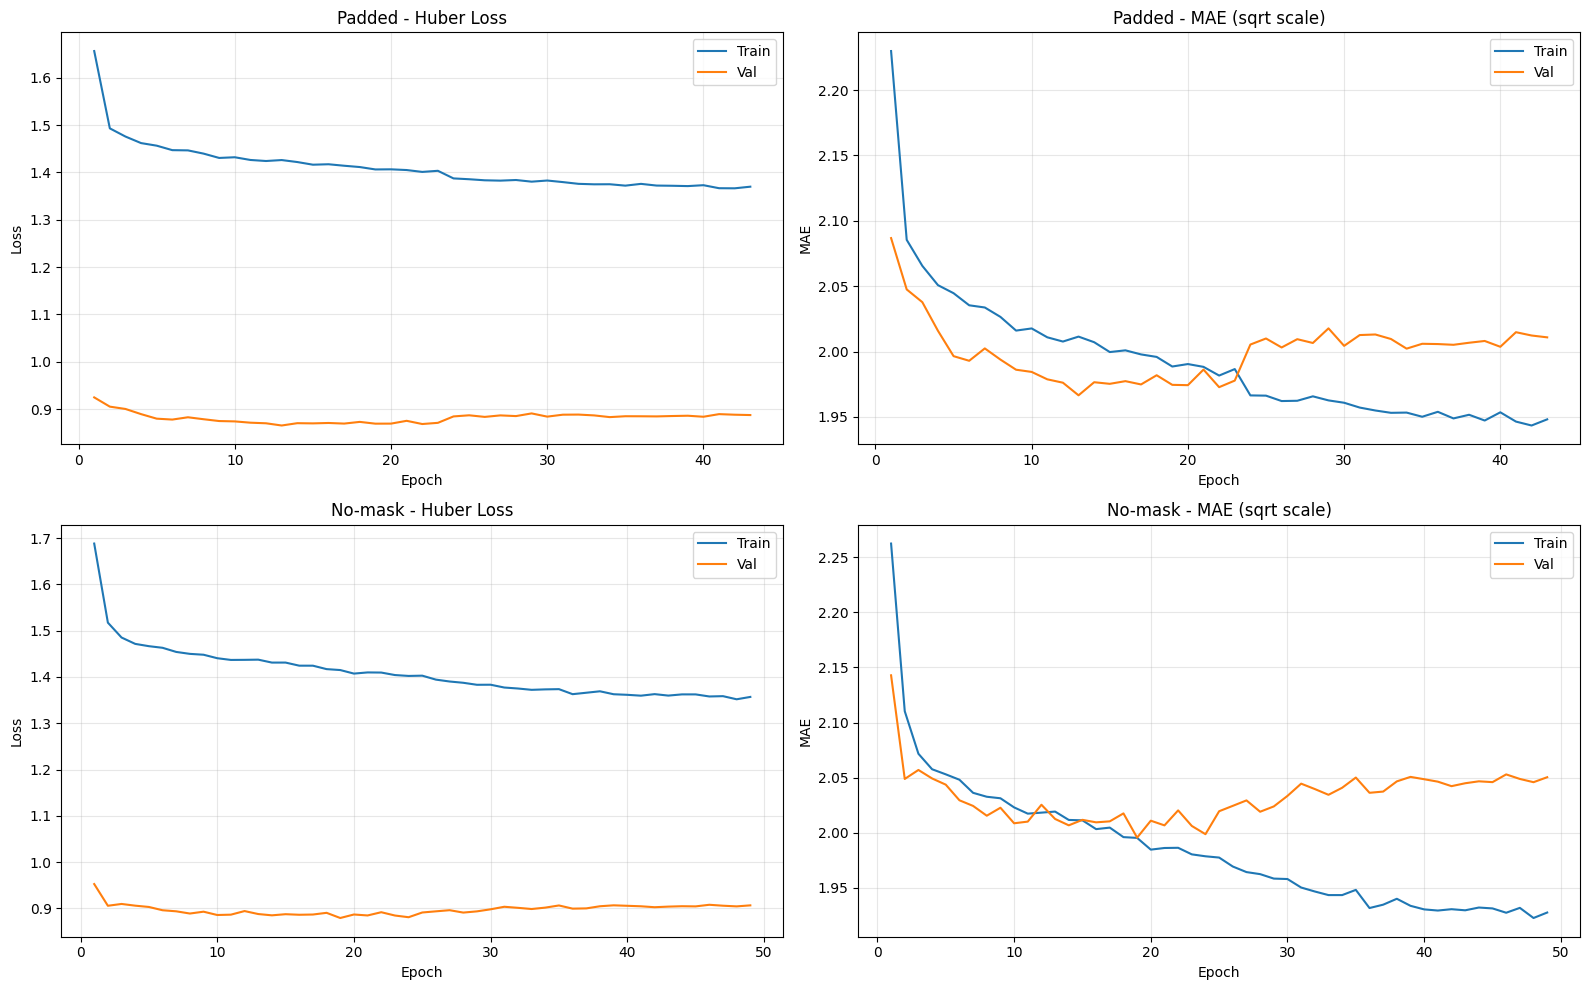

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for row, (hist, label) in enumerate([(history_rnn, 'Padded'), (history_rnn_nm, 'No-mask')]):
    epochs = range(1, len(hist.history['loss']) + 1)
    ax = axes[row, 0]
    ax.plot(epochs, hist.history['loss'], label='Train', linewidth=1.5)
    ax.plot(epochs, hist.history['val_loss'], label='Val', linewidth=1.5)
    ax.set_title(f'{label} - Huber Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    ax.plot(epochs, hist.history['mae'], label='Train', linewidth=1.5)
    ax.plot(epochs, hist.history['val_mae'], label='Val', linewidth=1.5)
    ax.set_title(f'{label} - MAE (sqrt scale)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MAE')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/rnn_v2_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 14. Full Comparison

In [15]:
reference_results = {
    'XGBoost (184 feat)':           {'Test MAE': 18.15, 'Test RMSE': 25.15, 'Test R2': 0.3335, 'Type': 'Tree'},
    'LightGBM (184 feat)':          {'Test MAE': 18.15, 'Test RMSE': 25.13, 'Test R2': 0.3346, 'Type': 'Tree'},
    'MLP-B (40 feat)':              {'Test MAE': 18.19, 'Test RMSE': 25.23, 'Test R2': 0.3289, 'Type': 'MLP'},
    'MLP-E Hybrid (40 feat)':       {'Test MAE': 17.88, 'Test RMSE': 25.35, 'Test R2': 0.3225, 'Type': 'MLP'},
    'MLP-D Fixed Hybrid (40 feat)': {'Test MAE': 17.83, 'Test RMSE': 25.67, 'Test R2': 0.3055, 'Type': 'MLP'},
    'Original RNN (184 feat)':      {'Test MAE': 19.73, 'Test RMSE': 27.93, 'Test R2': 0.2157, 'Type': 'RNN (old)'},
    'Original TCN (184 feat)':      {'Test MAE': 19.30, 'Test RMSE': 27.59, 'Test R2': 0.2453, 'Type': 'TCN (old)'},
}

reference_results['RNN v2 (padded)'] = {
    'Test MAE': round(mae_padded, 2), 'Test RMSE': round(rmse_padded, 2),
    'Test R2': round(r2_padded, 4), 'Type': 'RNN (v2)',
}
reference_results['RNN v2 (no-mask)'] = {
    'Test MAE': round(mae_nm, 2), 'Test RMSE': round(rmse_nm, 2),
    'Test R2': round(r2_nm, 4), 'Type': 'RNN (v2)',
}

comp_df = pd.DataFrame(reference_results).T
comp_df.index.name = 'Model'
comp_df = comp_df.sort_values('Test R2', ascending=False)
print(comp_df[['Type', 'Test MAE', 'Test RMSE', 'Test R2']].to_string())


                                   Type Test MAE Test RMSE Test R2
Model                                                             
LightGBM (184 feat)                Tree    18.15     25.13  0.3346
XGBoost (184 feat)                 Tree    18.15     25.15  0.3335
MLP-B (40 feat)                     MLP    18.19     25.23  0.3289
RNN v2 (padded)                RNN (v2)    18.13     25.27  0.3268
MLP-E Hybrid (40 feat)              MLP    17.88     25.35  0.3225
RNN v2 (no-mask)               RNN (v2)    18.78      25.9  0.3168
MLP-D Fixed Hybrid (40 feat)        MLP    17.83     25.67  0.3055
Original TCN (184 feat)       TCN (old)     19.3     27.59  0.2453
Original RNN (184 feat)       RNN (old)    19.73     27.93  0.2157


---
## 15. Save Results

In [16]:
output = {
    'best_params': rnn_study.best_params,
    'best_val_rmse': rnn_study.best_value,
    'padded': {
        'test_mae': round(mae_padded, 4),
        'test_rmse': round(rmse_padded, 4),
        'test_r2': round(r2_padded, 4),
        'training_metrics': metrics_padded,
    },
    'no_mask': {
        'seq_len': nomask_seq_len,
        'n_train': int(len(y_tr_orig_nm)),
        'n_test': int(len(y_te_orig_nm)),
        'test_mae': round(mae_nm, 4),
        'test_rmse': round(rmse_nm, 4),
        'test_r2': round(r2_nm, 4),
        'training_metrics': metrics_nm,
    },
    'seq_feature_cols': seq_feature_cols,
    'static_feature_cols': static_feature_cols,
    'n_seq_features': n_seq_features,
    'n_static_features': n_static_features,
}

with open('../results/rnn_v2_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

comp_df.to_csv('../results/rnn_v2_comparison.csv')
print('Saved: results/rnn_v2_results.json')
print('Saved: results/rnn_v2_comparison.csv')


Saved: results/rnn_v2_results.json
Saved: results/rnn_v2_comparison.csv
